# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

In [2]:
chembl_df = pd.read_csv("ChEMBL_200-500_10k.csv")
chembl_df.head()

chembl_df = chembl_df.sample(3000, random_state=42)



In [9]:
chembl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ChEMBL ID           10000 non-null  object 
 1   Name                182 non-null    object 
 2   Synonyms            82 non-null     object 
 3   Type                10000 non-null  object 
 4   Max Phase           75 non-null     float64
 5   Molecular Weight    10000 non-null  float64
 6   Targets             9593 non-null   float64
 7   Bioactivities       9593 non-null   float64
 8   AlogP               9946 non-null   float64
 9   Polar Surface Area  9946 non-null   float64
 10  HBA                 9946 non-null   float64
 11  HBD                 9946 non-null   float64
 12  #RO5 Violations     9946 non-null   float64
 13  #Rotatable Bonds    9946 non-null   float64
 14  Passes Ro3          9946 non-null   object 
 15  QED Weighted        9946 non-null   float64
 16  Aroma

In [3]:
chembl_df.isna().sum().sum()

np.int64(9595)

In [4]:
chembl_df.duplicated().sum().sum()

np.int64(0)

In [5]:
pubchem_df = pd.read_csv("pubchem_antibiotics.csv")
pubchem_df.head()

,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


In [6]:
pubchem_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Compound_CID                        2358 non-null   int64  
 1   Name                                2358 non-null   object 
 2   Synonyms                            2330 non-null   object 
 3   Molecular_Formula                   2358 non-null   object 
 4   InChI                               2358 non-null   object 
 5   Smiles                              2358 non-null   object 
 6   InChIKey                            2358 non-null   object 
 7   IUPAC_Name                          2348 non-null   object 
 8   MeSH_Headings                       1124 non-null   object 
 9   Annotation_Content                  2225 non-null   object 
 10  Linked_BioAssays                    1093 non-null   object 
 11  Data_Source                         2358 no

In [7]:
pubchem_df.isna().sum().sum()

np.int64(4048)

In [8]:
pubchem_df.duplicated().sum().sum()

np.int64(0)

Data cleaning

In [9]:
#standardizing column names

chembl_df.columns = chembl_df.columns.str.lower().str.replace(" ", "_")
chembl_df.columns


Index(['chembl_id', 'name', 'synonyms', 'type', 'max_phase',
       'molecular_weight', 'targets', 'bioactivities', 'alogp',
       'polar_surface_area', 'hba', 'hbd', '#ro5_violations',
       '#rotatable_bonds', 'passes_ro3', 'qed_weighted', 'aromatic_rings',
       'structure_type', 'inorganic_flag', 'heavy_atoms', 'np_likeness_score',
       'molecular_formula', 'smiles', 'inchi_key', 'inchi', 'withdrawn_flag',
       'orphan', 'records_key', 'records_name'],
      dtype='object')

In [10]:
pubchem_df.columns = pubchem_df.columns.str.lower().str.replace(" ", "_")
pubchem_df.columns

Index(['compound_cid', 'name', 'synonyms', 'molecular_formula', 'inchi',
       'smiles', 'inchikey', 'iupac_name', 'mesh_headings',
       'annotation_content', 'linked_bioassays', 'data_source',
       'data_source_category', 'tagged_by_pubchem', 'molecular_weight',
       'polar_area', 'complexity', 'xlogp', 'heavy_atom_count',
       'h-bond_donor_count', 'h-bond_acceptor_count', 'rotatable_bond_count',
       'exact_mass', 'monoisotopic_mass', 'charge', 'covalent_unit_count',
       'isotopic_atom_count', 'total_atom_stereo_count',
       'defined_atom_stereo_count', 'undefined_atom_stereo_count',
       'total_bond_stereo_count', 'defined_bond_stereo_count',
       'undefined_bond_stereo_count', 'linked_pubchem_literature_count',
       'linked_pubchem_patent_count', 'linked_pubchem_patent_family_count',
       'annotation_type_count', 'create_date'],
      dtype='object')

In [11]:
# only keeping relevant features
chembl_df = chembl_df[['chembl_id', 'smiles']]
pubchem_df = pubchem_df[['compound_cid', 'smiles']]

In [12]:
# renaming the remaining features in the same way
chembl_df = chembl_df.rename(columns={'chembl_id': 'id'})
pubchem_df = pubchem_df.rename(columns={'compound_cid': 'id'})

In [13]:
chembl_df.head()

,id,smiles
6252,CHEMBL4080795,O=c1c(NCc2ccccn2)c(-c2ccc(C(F)(F)F)cc2)c1=O
4684,CHEMBL2110942,CN(C)CC/C=C1\c2cc(Cl)ccc2CCn2cccc21
1731,CHEMBL370979,CSC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)C(N=[N+]=[N-...
4742,CHEMBL527159,COc1ccc2nccc(N3CCN(CCNCc4ccc5c(n4)NC(=O)CO5)CC...
4521,CHEMBL3274012,Cc1nn(C)c2nc3ccccc3c(NCCCN(C)C)c12.Cl


In [14]:
pubchem_df.head()

,id,smiles
0,16131155,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...
1,6439108,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C
2,9690107,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...
3,125607,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...
4,5487319,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...


In [15]:
chembl_df = chembl_df.dropna(subset=['smiles'])
pubchem_df = pubchem_df.dropna(subset=['smiles'])

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [16]:
normalizer = Normalizer()

def clean_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        mol = normalizer.normalize(mol)
        canonical = Chem.MolToSmiles(mol, canonical=True)
        return canonical
    
    except:
        return None

[18:42:52] Initializing Normalizer


In [17]:
chembl_df["canonical_smiles"] = chembl_df["smiles"].apply(clean_smiles)
pubchem_df["canonical_smiles"] = pubchem_df["smiles"].apply(clean_smiles)

[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55] Running Normalizer
[18:42:55]

In [18]:
# removing invalid molecules
chembl_df = chembl_df.dropna(subset=["canonical_smiles"]).reset_index(drop=True)
pubchem_df = pubchem_df.dropna(subset=["canonical_smiles"]).reset_index(drop=True)

In [19]:
# Morgan fingerprints
fpgen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2, fpSize=2048)

In [21]:
def generate_fingerprints(df):

    fp_list = []
    mol_list = []

    for smi in df["canonical_smiles"]:
        
        mol = Chem.MolFromSmiles(smi)
        
        if mol:
            mol_list.append(mol)
            fp = fpgen.GetFingerprint(mol)
            fp_list.append(fp)

    return mol_list, fp_list

In [22]:
chembl_mols, chembl_fps = generate_fingerprints(chembl_df)
pubchem_mols, pubchem_fps = generate_fingerprints(pubchem_df)

[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors
[18:43:15] WARNING: not removing hydrogen atom without neighbors


In [23]:
# converting fingerprints to numpy

def fps_to_numpy(fp_list):

    nfps = len(fp_list)
    X = np.zeros((nfps, 2048), dtype=int)

    for i, fp in enumerate(fp_list):
        DataStructs.ConvertToNumpyArray(fp, X[i])

    return X

Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [ ]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
dists = []
nfps = len(fp_list)

for i in range(1, nfps):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters))


# i will make a function out of simplicity since we have two datasets

In [25]:
def run_butina(fp_list, cutoff=0.6):

    dists = []
    nfps = len(fp_list)

    for i in range(1, nfps):
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend([1-x for x in similarities])

    clusters = Butina.ClusterData(
        dists,
        nfps,
        cutoff,
        isDistData=True
    )

    return clusters

In [26]:
chembl_clusters = run_butina(chembl_fps)
pubchem_clusters = run_butina(pubchem_fps)

In [ ]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

# i will make a function out of simplicity since we have two datasets

In [28]:
def butina_clusters(butina_clusters, nfps, min_size=10):

    # filter out small clusters
    clusters_filtered = [c for c in butina_clusters if len(c) >= min_size]

    # initialize labels
    butina_labels = np.full(nfps, -1)

    # assign cluster labels
    for cluster_id, cluster in enumerate(clusters_filtered):
        for idx in cluster:
            butina_labels[idx] = cluster_id

    # cluster sizes
    sizes = [len(c) for c in clusters_filtered]

    print("clusters:", len(sizes))
    print("mean size:", np.mean(sizes))
    print("max size:", np.max(sizes))
    print("singletons:", sum(s == 1 for s in sizes))

    return clusters_filtered, butina_labels, sizes

In [30]:
chembl_clusters_filtered, chembl_labels, chembl_sizes = butina_clusters(
    chembl_clusters,len(chembl_fps),min_size=10)

clusters: 1
mean size: 10.0
max size: 10
singletons: 0


In [31]:
pubchem_clusters_filtered, pubchem_labels, pubchem_sizes = butina_clusters(
    pubchem_clusters,
    len(pubchem_fps),
    min_size=10
)

clusters: 49
mean size: 28.06122448979592
max size: 125
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [33]:
## this time not with function first for chembl_df
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

chembl_hdbs_labels = hdbs_clustering.fit_predict(chembl_fps)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [34]:
## now for oubchem_df
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

pubchem_hdbs_labels = hdbs_clustering.fit_predict(pubchem_fps)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [35]:
print("Number of DBSCAN clusters:",
      len(set(chembl_hdbs_labels)) - (1 if -1 in chembl_hdbs_labels else 0))
print("Noise points:", list(chembl_hdbs_labels).count(-1))

Number of DBSCAN clusters: 2
Noise points: 2808


In [36]:
print("Number of DBSCAN clusters:",
      len(set(pubchem_hdbs_labels)) - (1 if -1 in pubchem_hdbs_labels else 0))
print("Noise points:", list(pubchem_hdbs_labels).count(-1))

Number of DBSCAN clusters: 56
Noise points: 1045


Embeddings: TSNE and UMAP

In [40]:
X_chembl = fps_to_numpy(chembl_fps)

In [41]:
X_pubchem = fps_to_numpy(pubchem_fps)

In [48]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

chembl_umap_embedding = umap_model.fit_transform(X_chembl)

c:\Users\fabie\DSA104_git\DSA104Fork\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\fabie\DSA104_git\DSA104Fork\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [49]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

pubchem_umap_embedding = umap_model.fit_transform(X_pubchem)

c:\Users\fabie\DSA104_git\DSA104Fork\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\fabie\DSA104_git\DSA104Fork\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [50]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

chembl_tsne_embedding = tsne_model.fit_transform(X_chembl)

In [51]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

pubchem_tsne_embedding = tsne_model.fit_transform(X_pubchem)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

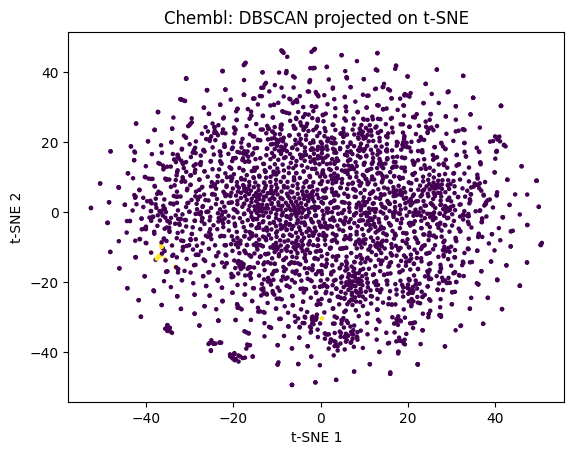

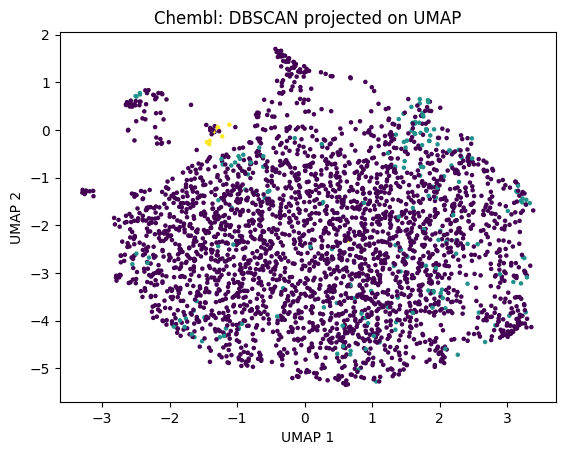

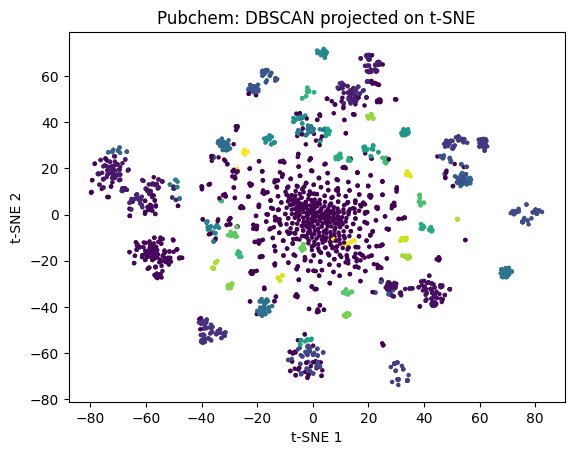

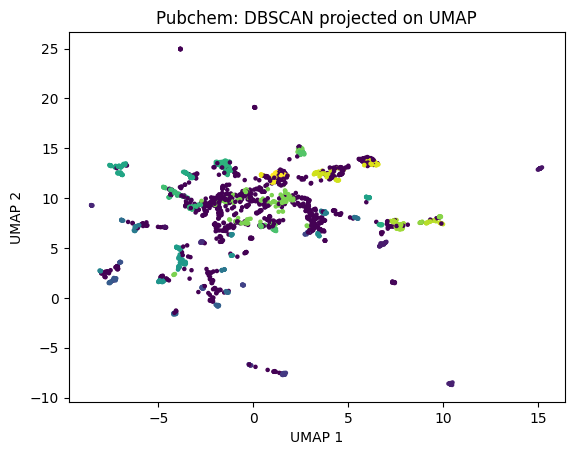

In [71]:
# chembl t-SNE plot
plt.figure()
plt.scatter(chembl_tsne_embedding[:, 0], chembl_tsne_embedding[:, 1], c=chembl_labels, s=5)
plt.title("Chembl: DBSCAN projected on t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(chembl_umap_embedding[:, 0], chembl_umap_embedding[:, 1], c=chembl_hdbs_labels, s=5)
plt.title("Chembl: DBSCAN projected on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# pubchem t-SNE plot
plt.figure()
plt.scatter(pubchem_tsne_embedding[:, 0], pubchem_tsne_embedding[:, 1], c=pubchem_labels, s=5)
plt.title("Pubchem: DBSCAN projected on t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(pubchem_umap_embedding[:, 0], pubchem_umap_embedding[:, 1], c=pubchem_hdbs_labels, s=5)
plt.title("Pubchem: DBSCAN projected on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

In [72]:
chembl_df["Butina_cluster"] = chembl_labels
chembl_df["HDBSCAN_cluster"] = chembl_hdbs_labels

pubchem_df["Butina_cluster"] = pubchem_labels
pubchem_df["HDBSCAN_cluster"] = pubchem_hdbs_labels

In [ ]:

def representative_molecules(df, labels_col, smiles_col="smiles", top_n=3):
   
    # Count cluster sizes
    cluster_sizes = df[labels_col].value_counts()
    top_clusters = cluster_sizes.head(top_n).index.tolist()
    
    mols_to_show = []
    
    for c in top_clusters:
        cluster_df = df[df[labels_col] == c]
        # Take the first valid SMILES as representative
        for smi in cluster_df[smiles_col]:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mols_to_show.append(mol)
                break  # only 1 per cluster
                
    img = Draw.MolsToGridImage(mols_to_show, molsPerRow=top_n, subImgSize=(200,200))
    display(img)

chembl butina


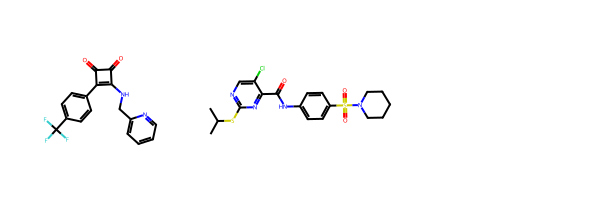

chembl HDBSCAN


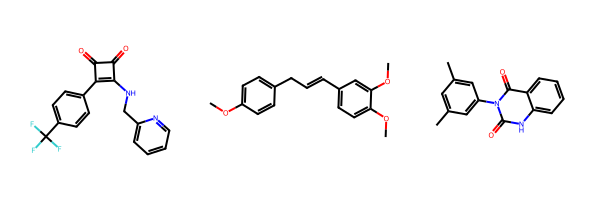

pubchem butina


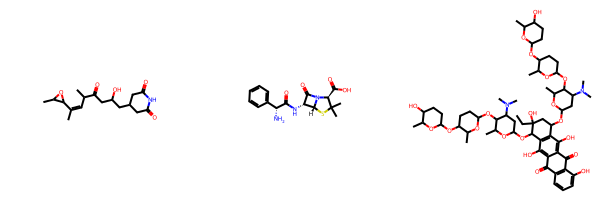

pubchem HBDSCAN 


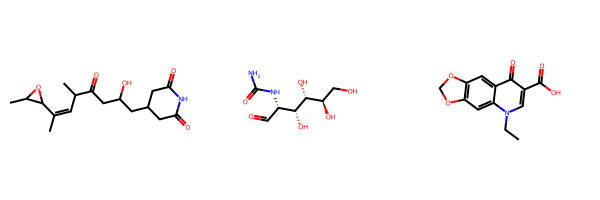

In [79]:


print("chembl butina")
representative_molecules(chembl_df, "Butina_cluster")

print("chembl HDBSCAN")
representative_molecules(chembl_df, "HDBSCAN_cluster")

print("pubchem butina")
representative_molecules(pubchem_df, "Butina_cluster", smiles_col="smiles")

print("pubchem HBDSCAN ")
representative_molecules(pubchem_df, "HDBSCAN_cluster", smiles_col="smiles")

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


1) 
Chembl: small, diverse molecules MW 250-500
pubchem: larger, more complex moleculse, grouped by antibiotic class
difference: chembl is broad and diverse, pubchem is biased

2) 
butina: similarity based; groups molecules by structural similarity "interpretable families"
hdbscan: density based; finds dense clusters, leaves sparse molecules as noise => good for datasets with natural dense families

3)
butina: tanimoto cutoff 0.6
hdbscan: min cluster size: 5-20, min samples: 2-5

4)
t-SNE: emphasizes local neighbourhoods, tight clusters
umap: preserves global and local structure: faster => better for large datasets

5)
chembl: umap + butina => capture families while showing overall chemical diversity
pubchem: t-SNE + hdbscan => highlights dense classes and separates outliers

6)
- large datasets => slow runtime on hdbscan or and t-SNE
- many small clusters => tune parameters or some merge clusters
- fingerprint choise and feature / dimensionality reduction affect results

7)
clusters refelct known antibiotic classes:
- aminoglycosides (the large one)
- beta-lactams (to the left of the large one)
- the other i cannot confidently classify


